In [2]:
!pip install librosa soundfile tensorflow scikit-learn matplotlib seaborn pandas streamlit

In [3]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    LSTM,
    Bidirectional
)

print("TensorFlow:", tf.__version__)
print("Setup successful!")

TensorFlow: 2.21.0
Setup successful!


In [4]:
dataset_path = "dataset"

print(os.listdir(dataset_path))

['Actor_01', 'Actor_02', 'Actor_03', 'Actor_04', 'Actor_05', 'Actor_06', 'Actor_07', 'Actor_08', 'Actor_09', 'Actor_10', 'Actor_11', 'Actor_12', 'Actor_13', 'Actor_14', 'Actor_15', 'Actor_16', 'Actor_17', 'Actor_18', 'Actor_19', 'Actor_20', 'Actor_21', 'Actor_22', 'Actor_23', 'Actor_24']


In [5]:
audio_files = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".wav"):
            audio_files.append(os.path.join(root, file))

print("Total audio files:", len(audio_files))

Total audio files: 1440


In [6]:
emotion_labels = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

In [7]:
file = audio_files[0]

print(file)

dataset\Actor_01\03-01-01-01-01-01-01.wav


In [8]:
def preprocess_audio(file_path):

    audio, sr = librosa.load(
        file_path,
        sr=16000,
        mono=True
    )

    # Normalize
    audio = librosa.util.normalize(audio)

    return audio, sr

In [9]:
audio, sr = preprocess_audio(audio_files[0])

print("Sampling rate:", sr)
print("Audio length:", len(audio))

Sampling rate: 16000
Audio length: 52853


In [17]:
def extract_features(file_path):

    audio, sr = preprocess_audio(file_path)

    # MFCC
    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=40
    )

    # Make every MFCC exactly 130 time frames
    mfcc = librosa.util.fix_length(
        mfcc,
        size=130,
        axis=1
    )

    # Mel Spectrogram
    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_mels=40
    )

    mel_db = librosa.power_to_db(mel)

    # Zero Crossing Rate
    zcr = librosa.feature.zero_crossing_rate(audio)

    # Energy
    energy = librosa.feature.rms(y=audio)

    # Pitch
    pitch, magnitude = librosa.piptrack(
        y=audio,
        sr=sr
    )

    pitch_mean = np.mean(pitch)

    return mfcc, mel_db, zcr, energy, pitch_mean

In [18]:
mfcc, mel, zcr, energy, pitch = extract_features(audio_files[0])

print("MFCC:", mfcc.shape)
print("Mel:", mel.shape)
print("ZCR:", zcr.shape)
print("Energy:", energy.shape)
print("Pitch:", pitch)

MFCC: (40, 130)
Mel: (40, 104)
ZCR: (1, 104)
Energy: (1, 104)
Pitch: 91.73607


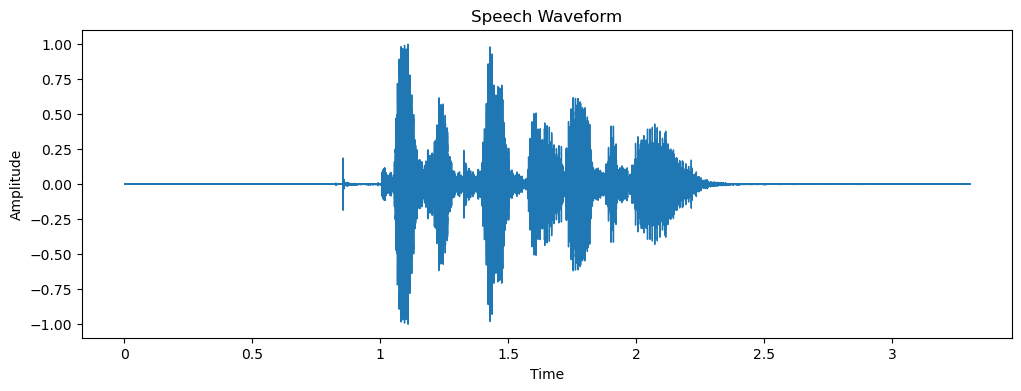

In [19]:
audio, sr = preprocess_audio(audio_files[0])

plt.figure(figsize=(12,4))

librosa.display.waveshow(
    audio,
    sr=sr
)

plt.title("Speech Waveform")
plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.show()

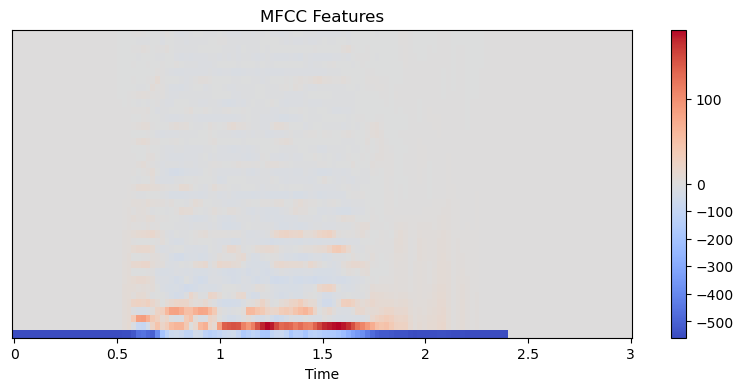

In [20]:
plt.figure(figsize=(10,4))

librosa.display.specshow(
    mfcc,
    x_axis="time"
)

plt.colorbar()
plt.title("MFCC Features")

plt.show()

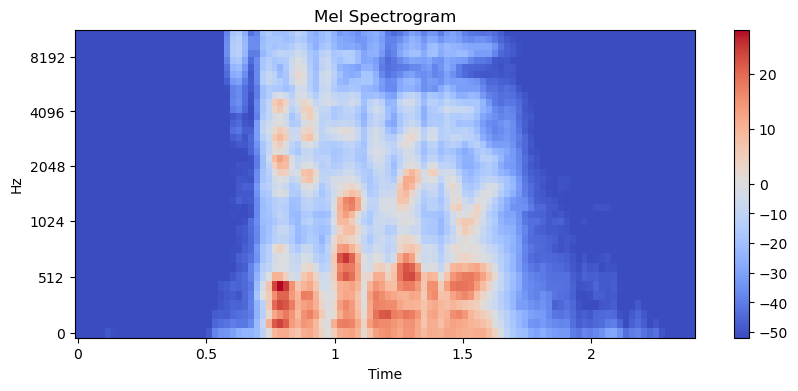

In [21]:
plt.figure(figsize=(10,4))

librosa.display.specshow(
    mel,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar()
plt.title("Mel Spectrogram")

plt.show()

In [22]:
X = []
y = []

for i, file in enumerate(audio_files):

    try:

        mfcc, mel, zcr, energy, pitch = extract_features(file)

        # Store MFCC
        X.append(mfcc)

        # Get emotion from filename
        filename = os.path.basename(file)
        emotion_code = filename.split("-")[2]
        emotion = emotion_labels[emotion_code]

        y.append(emotion)

    except Exception as e:
        print("Error:", file, e)

    if (i + 1) % 100 == 0:
        print(i + 1, "files processed")

print("Finished!")

100 files processed
200 files processed
300 files processed
400 files processed
500 files processed
600 files processed
700 files processed
800 files processed
900 files processed
1000 files processed
1100 files processed
1200 files processed
1300 files processed
1400 files processed
Finished!


In [23]:
X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1440, 40, 130)
y shape: (1440,)


In [24]:
print(X[0].shape)
print(y[0])

(40, 130)
neutral


In [25]:
encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

print("Emotion classes:")
print(encoder.classes_)

Emotion classes:
['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1152
Testing samples: 288


In [27]:
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (1152, 40, 130, 1)
X_test: (288, 40, 130, 1)


In [29]:
from tensorflow.keras import Input

cnn_model = Sequential([
    
    Input(shape=X_train.shape[1:]),
    
    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    
    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    
    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    
    Flatten(),
    
    Dense(128, activation="relu"),
    
    Dropout(0.3),
    
    Dense(
        len(encoder.classes_),
        activation="softmax"
    )
])

In [30]:
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 38, 128, 32)         │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 19, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 17, 62, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 8, 31, 64)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 6, 29, 128)          │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 3, 14, 128)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 5376)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         688,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 8)                   │           1,032 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 781,960 (2.98 MB)

 Trainable params: 781,960 (2.98 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [33]:
cnn_history = cnn_model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.1401 - loss: 4.6398 - val_accuracy: 0.2511 - val_loss: 2.0033
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.2530 - loss: 1.9279 - val_accuracy: 0.2814 - val_loss: 1.8519
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.3203 - loss: 1.7722 - val_accuracy: 0.3593 - val_loss: 1.6919
Epoch 4/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.3833 - loss: 1.6430 - val_accuracy: 0.3593 - val_loss: 1.6514
Epoch 5/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.4321 - loss: 1.5411 - val_accuracy: 0.4545 - val_loss: 1.4636
Epoch 6/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.5320 - loss: 1.3012 - val_accuracy: 0.4459 - val_loss: 1.4911
Epoch 7/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.5624 - loss: 1.1732 - val_accuracy: 0.4978 - val_loss: 1.3523
Epoch 8/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.6515 - loss: 1.0063 - val_accuracy: 0.5238 - v

In [34]:
test_loss, test_accuracy = cnn_model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5347 - loss: 2.3216
Test Loss: 2.32157826423645
Test Accuracy: 0.5347222089767456


In [35]:
y_pred_prob = cnn_model.predict(X_test)

y_pred = np.argmax(y_pred_prob, axis=1)

print("Predictions generated!")

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Predictions generated!


In [36]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

       angry       0.72      0.74      0.73        38
        calm       0.66      0.66      0.66        38
     disgust       0.51      0.50      0.51        38
     fearful       0.67      0.41      0.51        39
       happy       0.34      0.44      0.38        39
     neutral       0.32      0.58      0.42        19
         sad       0.45      0.13      0.20        38
   surprised       0.60      0.85      0.70        39

    accuracy                           0.53       288
   macro avg       0.53      0.54      0.51       288
weighted avg       0.55      0.53      0.52       288



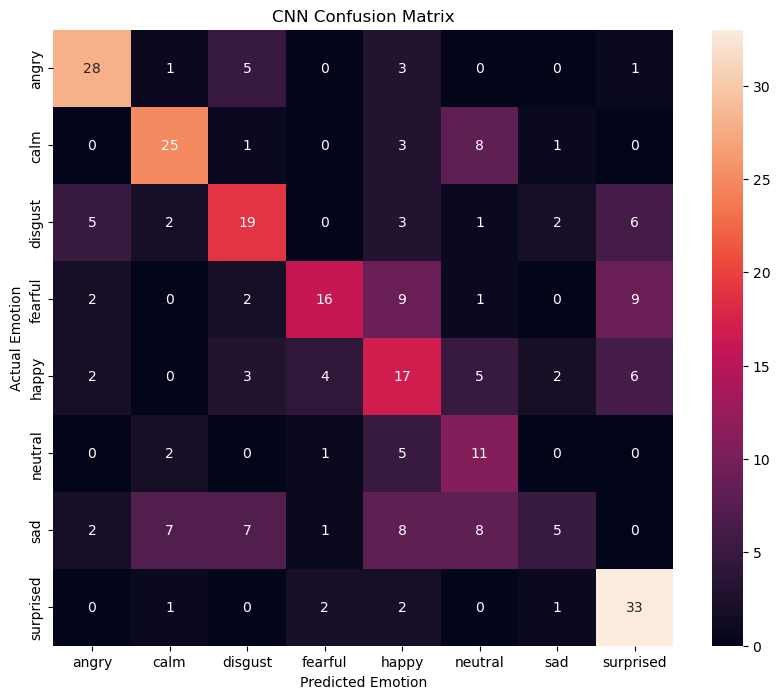

In [37]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")
plt.title("CNN Confusion Matrix")

plt.show()

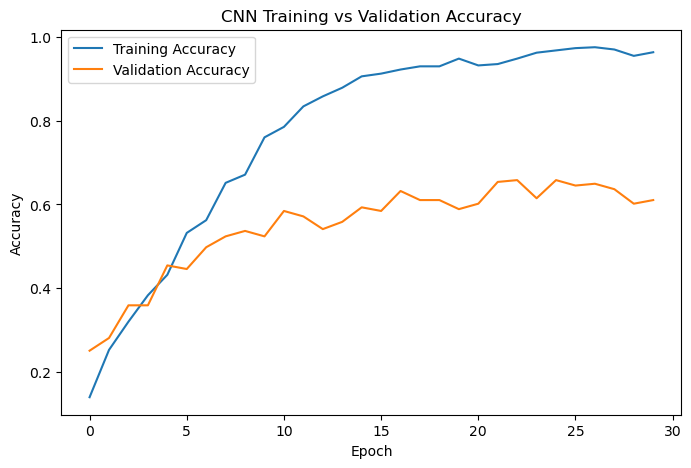

In [38]:
plt.figure(figsize=(8, 5))

plt.plot(
    cnn_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    cnn_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training vs Validation Accuracy")
plt.legend()

plt.savefig(
    "graphs/cnn_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

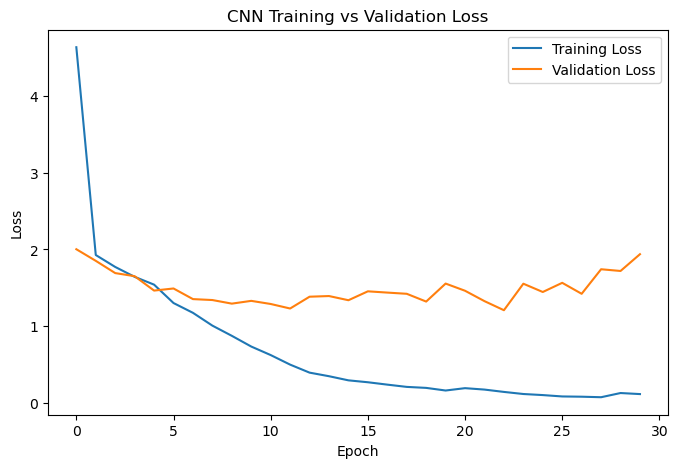

In [39]:
plt.figure(figsize=(8, 5))

plt.plot(
    cnn_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    cnn_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training vs Validation Loss")
plt.legend()

plt.savefig(
    "graphs/cnn_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

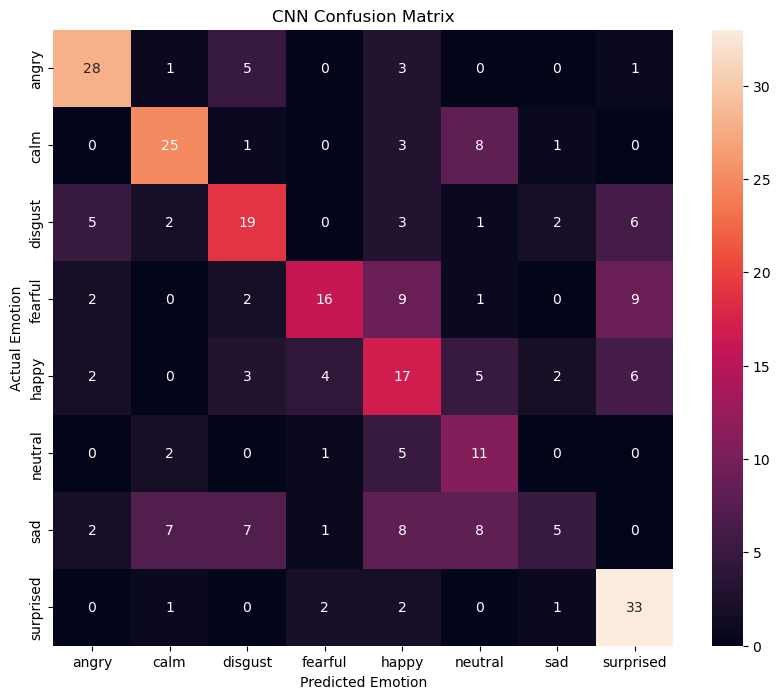

In [41]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")
plt.title("CNN Confusion Matrix")

plt.show()

In [42]:
cnn_model.save("models/cnn_baseline.keras")

In [43]:
import os

print(os.path.exists("models/cnn_baseline.keras"))

True


In [44]:
import pickle

with open("models/label_encoder.pkl", "wb") as f:
    pickle.dump(encoder, f)

print("Label encoder saved!")

Label encoder saved!


In [45]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dropout,
    TimeDistributed,
    Flatten,
    Bidirectional,
    LSTM,
    Dense
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [47]:
from tensorflow.keras.layers import Permute

In [48]:
input_layer = Input(shape=X_train.shape[1:])

# CNN feature extraction
x = Conv2D(32, (3, 3), activation="relu", padding="same")(input_layer)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)

x = Conv2D(64, (3, 3), activation="relu", padding="same")(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)

x = Conv2D(128, (3, 3), activation="relu", padding="same")(x)
x = BatchNormalization()(x)

# Convert CNN feature maps into a sequence
x = Permute((2, 1, 3))(x)

x = TimeDistributed(Flatten())(x)

# Bidirectional LSTM
x = Bidirectional(
    LSTM(128, return_sequences=False)
)(x)

x = Dropout(0.4)(x)

# Fully connected layer
x = Dense(128, activation="relu")(x)

x = Dropout(0.3)(x)

# Output layer
output_layer = Dense(
    len(encoder.classes_),
    activation="softmax"
)(x)

cnn_bilstm = Model(
    inputs=input_layer,
    outputs=output_layer
)

cnn_bilstm.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 40, 130, 1)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 40, 130, 32)         │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 40, 130, 32)         │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 20, 65, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 20, 65, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 20, 65, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 10, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 10, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 10, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ permute (Permute)                    │ (None, 32, 10, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed (TimeDistributed)   │ (None, 32, 1280)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 256)                 │       1,442,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 8)                   │           1,032 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,570,312 (5.99 MB)

 Trainable params: 1,569,864 (5.99 MB)

 Non-trainable params: 448 (1.75 KB)

In [50]:
cnn_bilstm.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [51]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

In [52]:
bilstm_history = cnn_bilstm.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 218ms/step - accuracy: 0.1607 - loss: 2.1035 - val_accuracy: 0.1991 - val_loss: 1.9976 - learning_rate: 0.0010
Epoch 2/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 188ms/step - accuracy: 0.2096 - loss: 1.9985 - val_accuracy: 0.2381 - val_loss: 1.9084 - learning_rate: 0.0010
Epoch 3/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 191ms/step - accuracy: 0.2562 - loss: 1.9256 - val_accuracy: 0.2468 - val_loss: 1.8380 - learning_rate: 0.0010
Epoch 4/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 194ms/step - accuracy: 0.2595 - loss: 1.8749 - val_accuracy: 0.3160 - val_loss: 1.7808 - learning_rate: 0.0010
Epoch 5/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 191ms/step - accuracy: 0.2541 - loss: 1.8458 - val_accuracy: 0.3723 - val_loss: 1.7291 - learning_rate: 0.0010
Epoch 6/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 191ms/step - accuracy: 0.3257 - loss: 1.7760 - val_accuracy: 0.3160 - val_loss: 1.7128 - learning_rate: 0.0010
Epoch 7/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 192ms/step - accuracy: 0.3312 - loss: 1.7747 -

In [53]:
bilstm_test_loss, bilstm_test_accuracy = cnn_bilstm.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("CNN + BiLSTM Test Loss:", bilstm_test_loss)
print("CNN + BiLSTM Test Accuracy:", bilstm_test_accuracy)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5764 - loss: 1.1946
CNN + BiLSTM Test Loss: 1.1945868730545044
CNN + BiLSTM Test Accuracy: 0.5763888955116272


In [54]:
bilstm_pred_prob = cnn_bilstm.predict(X_test)

bilstm_pred = np.argmax(
    bilstm_pred_prob,
    axis=1
)

print("BiLSTM predictions generated!")

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
BiLSTM predictions generated!


In [55]:
print(
    classification_report(
        y_test,
        bilstm_pred,
        target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

       angry       0.84      0.82      0.83        38
        calm       0.62      0.68      0.65        38
     disgust       0.64      0.66      0.65        38
     fearful       0.51      0.67      0.58        39
       happy       0.50      0.28      0.36        39
     neutral       0.40      0.42      0.41        19
         sad       0.24      0.21      0.23        38
   surprised       0.70      0.79      0.75        39

    accuracy                           0.58       288
   macro avg       0.56      0.57      0.56       288
weighted avg       0.57      0.58      0.57       288



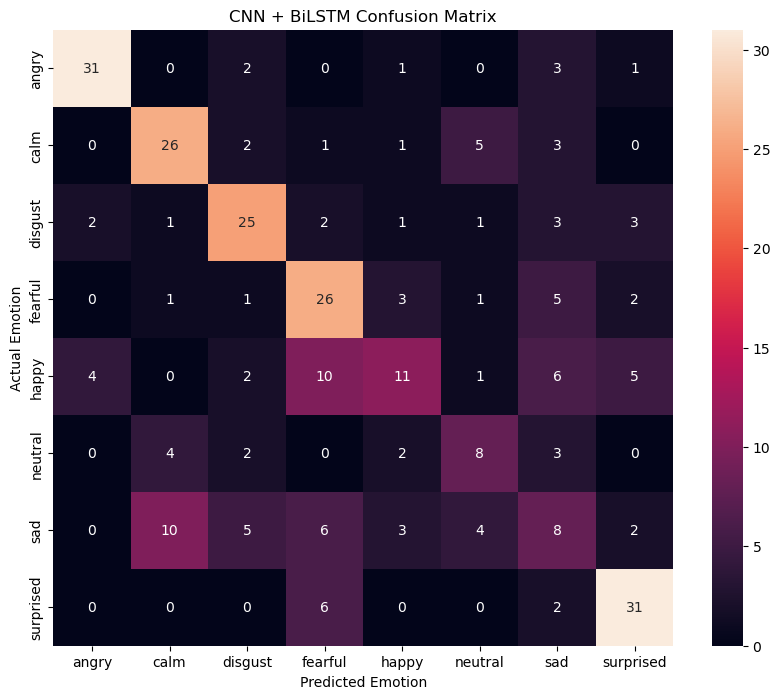

In [56]:
cm_bilstm = confusion_matrix(
    y_test,
    bilstm_pred
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_bilstm,
    annot=True,
    fmt="d",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")
plt.title("CNN + BiLSTM Confusion Matrix")

plt.show()

In [57]:
from tensorflow.keras.layers import Layer
import tensorflow as tf


class Attention(Layer):

    def __init__(self):
        super(Attention, self).__init__()

    def build(self, input_shape):

        self.W = self.add_weight(
            name="attention_weight",
            shape=(input_shape[-1], 1),
            initializer="normal",
            trainable=True
        )

        self.b = self.add_weight(
            name="attention_bias",
            shape=(input_shape[1], 1),
            initializer="zeros",
            trainable=True
        )

        super(Attention, self).build(input_shape)

    def call(self, x):

        e = tf.keras.backend.tanh(
            tf.keras.backend.dot(x, self.W) + self.b
        )

        a = tf.keras.backend.softmax(e, axis=1)

        output = x * a

        return tf.keras.backend.sum(
            output,
            axis=1
        )

In [55]:
input_layer = Input(shape=X_train.shape[1:])

# CNN
x = Conv2D(
    32, (3, 3),
    activation="relu",
    padding="same"
)(input_layer)

x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)

x = Conv2D(
    64, (3, 3),
    activation="relu",
    padding="same"
)(x)

x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)

x = Conv2D(
    128, (3, 3),
    activation="relu",
    padding="same"
)(x)

x = BatchNormalization()(x)

# Convert CNN output to sequence
x = Permute((2, 1, 3))(x)

x = TimeDistributed(
    Flatten()
)(x)

# BiLSTM
x = Bidirectional(
    LSTM(128, return_sequences=True)
)(x)

# Attention
x = Attention()(x)

# Classifier
x = Dropout(0.4)(x)

x = Dense(
    128,
    activation="relu"
)(x)

x = Dropout(0.3)(x)

output_layer = Dense(
    len(encoder.classes_),
    activation="softmax"
)(x)

cnn_bilstm_attention = Model(
    inputs=input_layer,
    outputs=output_layer
)

cnn_bilstm_attention.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 40, 130, 1)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 40, 130, 32)         │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 40, 130, 32)         │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 20, 65, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 20, 65, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 20, 65, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 10, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 10, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 10, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ permute (Permute)                    │ (None, 32, 10, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed (TimeDistributed)   │ (None, 32, 1280)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 32, 256)             │       1,442,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ attention_1 (Attention)              │ (None, 256)                 │             288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │           1,032 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,570,600 (5.99 MB)

 Trainable params: 1,570,152 (5.99 MB)

 Non-trainable params: 448 (1.75 KB)

In [59]:
cnn_bilstm_attention.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [60]:
attention_history = cnn_bilstm_attention.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=32,
    validation_split=0.2,
    callbacks=[
        early_stop,
        reduce_lr
    ]
)

Epoch 1/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 16s 245ms/step - accuracy: 0.1987 - loss: 2.0121 - val_accuracy: 0.1169 - val_loss: 2.0155 - learning_rate: 0.0010
Epoch 2/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 193ms/step - accuracy: 0.3105 - loss: 1.7873 - val_accuracy: 0.3290 - val_loss: 1.7663 - learning_rate: 0.0010
Epoch 3/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 196ms/step - accuracy: 0.3713 - loss: 1.6604 - val_accuracy: 0.3983 - val_loss: 1.6266 - learning_rate: 0.0010
Epoch 4/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 195ms/step - accuracy: 0.4321 - loss: 1.4705 - val_accuracy: 0.3766 - val_loss: 1.5831 - learning_rate: 0.0010
Epoch 5/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 195ms/step - accuracy: 0.5125 - loss: 1.2857 - val_accuracy: 0.4069 - val_loss: 1.4768 - learning_rate: 0.0010
Epoch 6/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 196ms/step - accuracy: 0.5711 - loss: 1.1842 - val_accuracy: 0.4589 - val_loss: 1.3963 - learning_rate: 0.0010
Epoch 7/40
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 197ms/step - accuracy: 0.6156 - loss: 1.0372 -

In [61]:
attention_test_loss, attention_test_accuracy = cnn_bilstm_attention.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("CNN + BiLSTM + Attention Test Loss:", attention_test_loss)
print("CNN + BiLSTM + Attention Test Accuracy:", attention_test_accuracy)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7222 - loss: 0.9824
CNN + BiLSTM + Attention Test Loss: 0.9823906421661377
CNN + BiLSTM + Attention Test Accuracy: 0.7222222089767456


In [62]:
attention_pred_prob = cnn_bilstm_attention.predict(X_test)

attention_pred = np.argmax(
    attention_pred_prob,
    axis=1
)

print("Attention predictions generated!")

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
Attention predictions generated!


In [63]:
print(
    classification_report(
        y_test,
        attention_pred,
        target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

       angry       0.83      0.76      0.79        38
        calm       0.74      0.82      0.78        38
     disgust       0.72      0.89      0.80        38
     fearful       0.65      0.82      0.73        39
       happy       0.76      0.41      0.53        39
     neutral       0.50      0.63      0.56        19
         sad       0.65      0.58      0.61        38
   surprised       0.89      0.82      0.85        39

    accuracy                           0.72       288
   macro avg       0.72      0.72      0.71       288
weighted avg       0.73      0.72      0.72       288



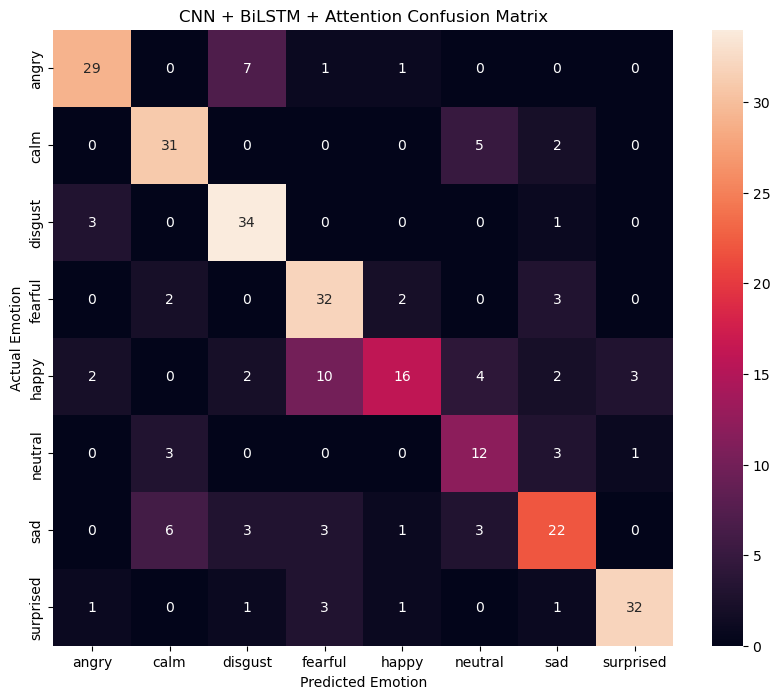

In [64]:
cm_attention = confusion_matrix(
    y_test,
    attention_pred
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_attention,
    annot=True,
    fmt="d",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")
plt.title("CNN + BiLSTM + Attention Confusion Matrix")

plt.show()

In [65]:
cnn_bilstm_attention.save(
    "models/emotion_cnn_bilstm_attention.keras"
)

print("Best model saved successfully!")

Best model saved successfully!


In [66]:
import os

print(
    os.path.exists(
        "models/emotion_cnn_bilstm_attention.keras"
    )
)

True


In [67]:
import pickle

with open("models/attention_history.pkl", "wb") as f:
    pickle.dump(attention_history.history, f)

print("Training history saved!")

Training history saved!


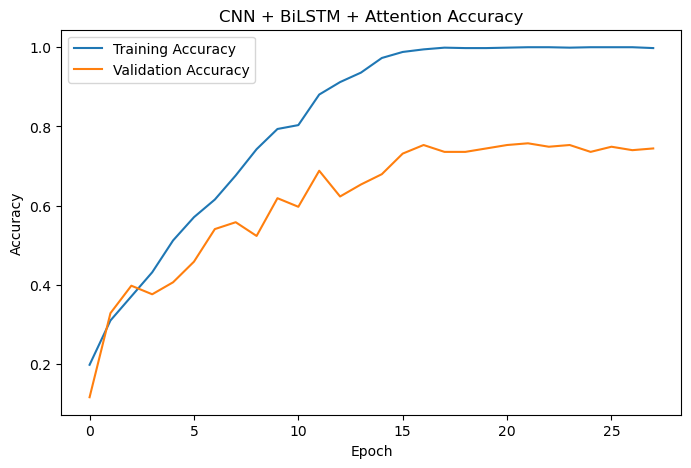

In [68]:
plt.figure(figsize=(8, 5))

plt.plot(
    attention_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    attention_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN + BiLSTM + Attention Accuracy")
plt.legend()

plt.savefig(
    "graphs/attention_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

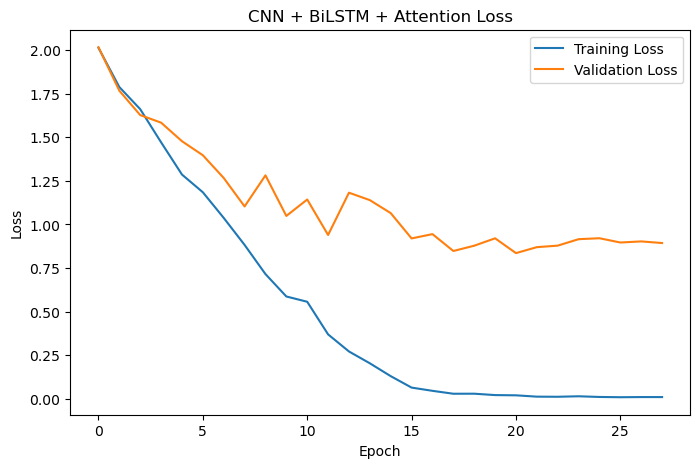

In [69]:
plt.figure(figsize=(8, 5))

plt.plot(
    attention_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    attention_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN + BiLSTM + Attention Loss")
plt.legend()

plt.savefig(
    "graphs/attention_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [71]:
!pip install pydub

In [1]:
print("Jupyter is working!")

Jupyter is working!


In [2]:
import numpy as np
import librosa
import tensorflow as tf

from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Layer

In [3]:
print("Jupyter is working!")

Jupyter is working!


In [4]:
import numpy as np
import librosa
import tensorflow as tf

from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Layer

In [7]:
class Attention(Layer):

    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)

    def build(self, input_shape):

        self.W = self.add_weight(
            name="attention_weight",
            shape=(input_shape[-1], 1),
            initializer="normal",
            trainable=True
        )

        self.b = self.add_weight(
            name="attention_bias",
            shape=(input_shape[1], 1),
            initializer="zeros",
            trainable=True
        )

        super(Attention, self).build(input_shape)

    def call(self, x):

        e = tf.keras.backend.tanh(
            tf.keras.backend.dot(x, self.W) + self.b
        )

        a = tf.keras.backend.softmax(e, axis=1)

        output = x * a

        return tf.keras.backend.sum(
            output,
            axis=1
        )

In [8]:
best_model = load_model(
    "models/emotion_cnn_bilstm_attention.keras",
    custom_objects={"Attention": Attention}
)

print("Best model loaded successfully!")


Best model loaded successfully!


In [9]:
print(best_model.input_shape)
print(best_model.output_shape)

(None, 40, 130, 1)
(None, 8)


In [10]:
import librosa
import numpy as np

audio_path = "test_audio/my_voice.wav"

audio, sr = librosa.load(
    audio_path,
    sr=22050
)

print("Audio loaded successfully!")
print("Sample rate:", sr)
print("Duration:", round(len(audio) / sr, 2), "seconds")

Audio loaded successfully!
Sample rate: 22050
Duration: 6.63 seconds


In [11]:
mfcc = librosa.feature.mfcc(
    y=audio,
    sr=sr,
    n_mfcc=40
)

print("Original MFCC shape:", mfcc.shape)

Original MFCC shape: (40, 286)


In [12]:
mfcc = librosa.util.fix_length(
    mfcc,
    size=130,
    axis=1
)

print("Final MFCC shape:", mfcc.shape)

Final MFCC shape: (40, 130)


In [13]:
X_voice = mfcc[np.newaxis, ..., np.newaxis]

print("Model input shape:", X_voice.shape)

Model input shape: (1, 40, 130, 1)


In [15]:
import numpy as np

emotion_labels = [
    "angry",
    "calm",
    "disgust",
    "fearful",
    "happy",
    "neutral",
    "sad",
    "surprised"
]

print(emotion_labels)

['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']


In [16]:
prediction = best_model.predict(X_voice)

predicted_index = np.argmax(prediction[0])

predicted_emotion = emotion_labels[predicted_index]

confidence = prediction[0][predicted_index] * 100

print("Predicted Emotion:", predicted_emotion)
print("Confidence:", round(confidence, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Predicted Emotion: calm
Confidence: 100.0 %


In [17]:
import matplotlib.pyplot as plt

probabilities = prediction[0] * 100

for emotion, probability in zip(emotion_labels, probabilities):
    print(f"{emotion:10s}: {probability:.2f}%")

angry     : 0.00%
calm      : 100.00%
disgust   : 0.00%
fearful   : 0.00%
happy     : 0.00%
neutral   : 0.00%
sad       : 0.00%
surprised : 0.00%


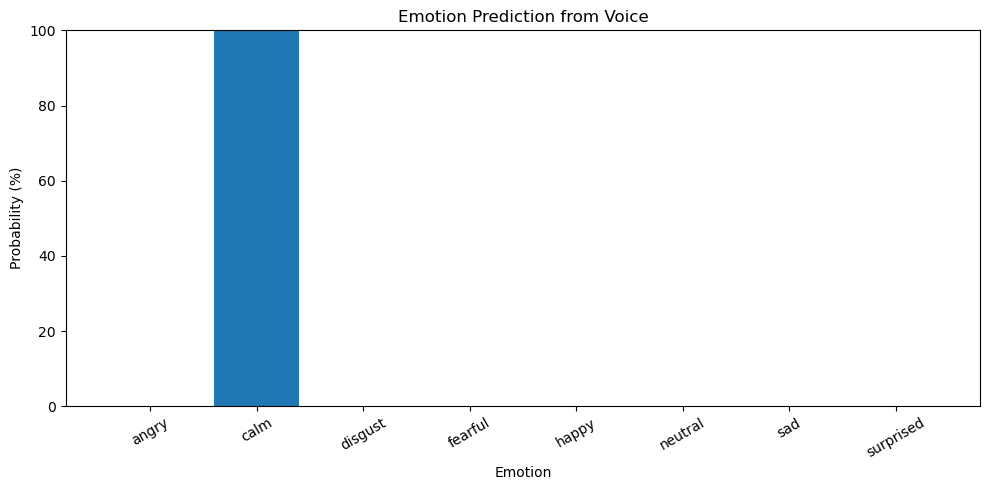

In [18]:
plt.figure(figsize=(10, 5))

plt.bar(emotion_labels, probabilities)

plt.xlabel("Emotion")
plt.ylabel("Probability (%)")
plt.title("Emotion Prediction from Voice")

plt.xticks(rotation=30)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

In [19]:
def predict_emotion(audio_path):

    audio, sr = librosa.load(
        audio_path,
        sr=22050
    )

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=40
    )

    mfcc = librosa.util.fix_length(
        mfcc,
        size=130,
        axis=1
    )

    X = mfcc[np.newaxis, ..., np.newaxis]

    prediction = best_model.predict(X, verbose=0)[0]

    predicted_index = np.argmax(prediction)

    emotion = emotion_labels[predicted_index]

    confidence = prediction[predicted_index] * 100

    return emotion, confidence

In [20]:
files = [
    "test_audio/my_voice.wav",
    "test_audio/normal.wav",
    "test_audio/happy.wav",
    "test_audio/angry.wav"
]

for file in files:

    emotion, confidence = predict_emotion(file)

    print("\nFile:", file)
    print("Predicted Emotion:", emotion)
    print("Confidence:", round(confidence, 2), "%")


File: test_audio/my_voice.wav
Predicted Emotion: calm
Confidence: 100.0 %

File: test_audio/normal.wav
Predicted Emotion: calm
Confidence: 100.0 %

File: test_audio/happy.wav
Predicted Emotion: calm
Confidence: 99.91 %

File: test_audio/angry.wav
Predicted Emotion: calm
Confidence: 99.97 %


In [22]:
print("Current variables loaded:")
print([x for x in dir() if not x.startswith("_")])

Current variables loaded:
['Attention', 'In', 'Layer', 'Out', 'X_voice', 'audio', 'audio_path', 'best_model', 'confidence', 'emotion', 'emotion_labels', 'exit', 'file', 'files', 'get_ipython', 'librosa', 'load_model', 'mfcc', 'np', 'open', 'pd', 'plt', 'predict_emotion', 'predicted_emotion', 'predicted_index', 'prediction', 'probabilities', 'probability', 'quit', 'sr', 'tf']


In [23]:
import os

print("Project files:")

for root, dirs, files in os.walk("."):
    level = root.count(os.sep)
    if level <= 2:
        print(root)
        for file in files[:10]:
            print("   ", file)

Project files:
.
    emotion_recognition.ipynb
.\.ipynb_checkpoints
    emotion_recognition-checkpoint.ipynb
.\app
.\dataset
.\dataset\Actor_01
    03-01-01-01-01-01-01.wav
    03-01-01-01-01-02-01.wav
    03-01-01-01-02-01-01.wav
    03-01-01-01-02-02-01.wav
    03-01-02-01-01-01-01.wav
    03-01-02-01-01-02-01.wav
    03-01-02-01-02-01-01.wav
    03-01-02-01-02-02-01.wav
    03-01-02-02-01-01-01.wav
    03-01-02-02-01-02-01.wav
.\dataset\Actor_02
    03-01-01-01-01-01-02.wav
    03-01-01-01-01-02-02.wav
    03-01-01-01-02-01-02.wav
    03-01-01-01-02-02-02.wav
    03-01-02-01-01-01-02.wav
    03-01-02-01-01-02-02.wav
    03-01-02-01-02-01-02.wav
    03-01-02-01-02-02-02.wav
    03-01-02-02-01-01-02.wav
    03-01-02-02-01-02-02.wav
.\dataset\Actor_03
    03-01-01-01-01-01-03.wav
    03-01-01-01-01-02-03.wav
    03-01-01-01-02-01-03.wav
    03-01-01-01-02-02-03.wav
    03-01-02-01-01-01-03.wav
    03-01-02-01-01-02-03.wav
    03-01-02-01-02-01-03.wav
    03-01-02-01-02-02-03.wav
    03

In [24]:
import os

dataset_path = "dataset"

print("Dataset exists:", os.path.exists(dataset_path))

if os.path.exists(dataset_path):
    print("Dataset contents:")
    print(os.listdir(dataset_path)[:20])

Dataset exists: True
Dataset contents:
['Actor_01', 'Actor_02', 'Actor_03', 'Actor_04', 'Actor_05', 'Actor_06', 'Actor_07', 'Actor_08', 'Actor_09', 'Actor_10', 'Actor_11', 'Actor_12', 'Actor_13', 'Actor_14', 'Actor_15', 'Actor_16', 'Actor_17', 'Actor_18', 'Actor_19', 'Actor_20']


In [25]:
import os
import librosa
import numpy as np

dataset_path = "dataset"

emotion_labels = [
    "angry",
    "calm",
    "disgust",
    "fearful",
    "happy",
    "neutral",
    "sad",
    "surprised"
]

emotion_map = {
    1: "neutral",
    2: "calm",
    3: "happy",
    4: "sad",
    5: "angry",
    6: "fearful",
    7: "disgust",
    8: "surprised"
}

print("Dataset found!")
print("Actors:", len(os.listdir(dataset_path)))

Dataset found!
Actors: 24


In [26]:
audio_files = []

for actor in os.listdir(dataset_path):

    actor_path = os.path.join(dataset_path, actor)

    if os.path.isdir(actor_path):

        for file in os.listdir(actor_path):

            if file.lower().endswith(".wav"):
                audio_files.append(
                    os.path.join(actor_path, file)
                )

print("Total WAV files:", len(audio_files))

Total WAV files: 1440


In [27]:
from collections import Counter

emotion_counts = Counter()

for file in audio_files:

    filename = os.path.basename(file)

    parts = filename.split("-")

    emotion_number = int(parts[2])

    emotion = emotion_map[emotion_number]

    emotion_counts[emotion] += 1

print(emotion_counts)

Counter({'calm': 192, 'happy': 192, 'sad': 192, 'angry': 192, 'fearful': 192, 'disgust': 192, 'surprised': 192, 'neutral': 96})


In [28]:
print("Available variables:")
print([x for x in dir() if x in [
    "X", "y", "X_train", "X_val", "X_test",
    "y_train", "y_val", "y_test",
    "history", "attention_history",
    "encoder", "scaler"
]])

Available variables:
[]


In [31]:
import os
import librosa
import numpy as np
from sklearn.model_selection import train_test_split

In [33]:
print("X exists:", "X" in globals())
print("y_encoded exists:", "y_encoded" in globals())

X exists: False
y_encoded exists: False


In [34]:
from sklearn.preprocessing import LabelEncoder
import numpy as np
import os

X = []
y = []

for file in audio_files:

    audio, sr = librosa.load(
        file,
        sr=22050
    )

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=40
    )

    mfcc = librosa.util.fix_length(
        mfcc,
        size=130,
        axis=1
    )

    X.append(mfcc)

    # Get emotion from filename
    filename = os.path.basename(file)
    emotion_number = int(filename.split("-")[2])

    y.append(emotion_map[emotion_number])

X = np.array(X)

print("X shape:", X.shape)
print("Number of labels:", len(y))

X shape: (1440, 40, 130)
Number of labels: 1440


In [35]:
encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

print("Classes:", encoder.classes_)
print("y shape:", y_encoded.shape)

Classes: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']
y shape: (1440,)


In [36]:
X = X[..., np.newaxis]

print("Final X shape:", X.shape)

Final X shape: (1440, 40, 130, 1)


In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1152
Testing samples: 288


In [38]:
test_loss, test_accuracy = best_model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.3125 - loss: 3.9163
Test Loss: 3.916262626647949
Test Accuracy: 0.3125


In [39]:
X = []
y = []

for file in audio_files:

    # Original preprocessing
    audio, sr = librosa.load(
        file,
        sr=16000,
        mono=True
    )

    # Normalize audio
    audio = librosa.util.normalize(audio)

    # MFCC
    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=40
    )

    # Make exactly 130 frames
    mfcc = librosa.util.fix_length(
        mfcc,
        size=130,
        axis=1
    )

    X.append(mfcc)

    # Get emotion from filename
    filename = os.path.basename(file)
    emotion_number = int(filename.split("-")[2])

    y.append(emotion_map[emotion_number])

X = np.array(X)

print("X shape:", X.shape)
print("Number of labels:", len(y))

X shape: (1440, 40, 130)
Number of labels: 1440


In [40]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

print("Classes:", encoder.classes_)

Classes: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


In [41]:
X = X[..., np.newaxis]

print("Final X shape:", X.shape)

Final X shape: (1440, 40, 130, 1)


In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1152
Testing samples: 288


In [43]:
test_loss, test_accuracy = best_model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7222 - loss: 0.9824
Test Loss: 0.9823906421661377
Test Accuracy: 0.7222222089767456


In [44]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

print("Classes:", encoder.classes_)

Classes: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


In [45]:
X = X[..., np.newaxis]

print("Final X shape:", X.shape)

Final X shape: (1440, 40, 130, 1, 1)


In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1152
Testing samples: 288


In [52]:
print("X shape:", X.shape)
print("X_train shape:", X_train.shape)

X shape: (1440, 40, 130, 1, 1)
X_train shape: (1152, 40, 130, 1, 1)


In [53]:
X = np.squeeze(X, axis=-1)

print("Corrected X shape:", X.shape)

Corrected X shape: (1440, 40, 130, 1)


In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (1152, 40, 130, 1)
X_test: (288, 40, 130, 1)


In [56]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (1152, 40, 130, 1)
X_test: (288, 40, 130, 1)


In [57]:
from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, MaxPooling2D,
    Permute, TimeDistributed, Flatten,
    Bidirectional, LSTM, Dropout, Dense
)
from tensorflow.keras.models import Model

input_layer = Input(shape=(40, 130, 1))

# CNN
x = Conv2D(32, (3, 3), activation="relu", padding="same")(input_layer)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)

x = Conv2D(64, (3, 3), activation="relu", padding="same")(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)

x = Conv2D(128, (3, 3), activation="relu", padding="same")(x)
x = BatchNormalization()(x)

# Convert CNN feature maps to sequence
x = Permute((2, 1, 3))(x)
x = TimeDistributed(Flatten())(x)

# BiLSTM
x = Bidirectional(
    LSTM(128, return_sequences=True)
)(x)

# Attention
x = Attention()(x)

# Classifier
x = Dropout(0.4)(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)

# Output
output_layer = Dense(
    len(encoder.classes_),
    activation="softmax"
)(x)

cnn_bilstm_attention = Model(
    inputs=input_layer,
    outputs=output_layer
)

cnn_bilstm_attention.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 40, 130, 1)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 40, 130, 32)         │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 40, 130, 32)         │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 20, 65, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 20, 65, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 20, 65, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 10, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 10, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 10, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ permute_1 (Permute)                  │ (None, 32, 10, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_1 (TimeDistributed) │ (None, 32, 1280)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 32, 256)             │       1,442,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ attention_2 (Attention)              │ (None, 256)                 │             288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 8)                   │           1,032 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,570,600 (5.99 MB)

 Trainable params: 1,570,152 (5.99 MB)

 Non-trainable params: 448 (1.75 KB)

In [58]:
cnn_bilstm_attention.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [59]:
import os

print(os.listdir("models"))

['attention_history.pkl', 'cnn_baseline.keras', 'emotion_cnn_bilstm_attention.keras', 'label_encoder.pkl']


In [60]:
import tensorflow as tf
from tensorflow.keras.layers import Layer

class Attention(Layer):

    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)

    def build(self, input_shape):

        self.W = self.add_weight(
            name="attention_weight",
            shape=(input_shape[-1], 1),
            initializer="normal",
            trainable=True
        )

        self.b = self.add_weight(
            name="attention_bias",
            shape=(input_shape[1], 1),
            initializer="zeros",
            trainable=True
        )

        super(Attention, self).build(input_shape)

    def call(self, x):

        e = tf.keras.backend.tanh(
            tf.keras.backend.dot(x, self.W) + self.b
        )

        a = tf.keras.backend.softmax(e, axis=1)

        output = x * a

        return tf.keras.backend.sum(
            output,
            axis=1
        )

    def get_config(self):
        config = super(Attention, self).get_config()
        return config

In [61]:
from tensorflow.keras.models import load_model

best_model = load_model(
    "models/emotion_cnn_bilstm_attention.keras",
    custom_objects={"Attention": Attention},
    compile=False
)

print("Best model loaded successfully!")

Best model loaded successfully!


In [62]:
print("Input shape:", best_model.input_shape)
print("Output shape:", best_model.output_shape)

Input shape: (None, 40, 130, 1)
Output shape: (None, 8)


In [63]:
predictions = best_model.predict(
    X_test,
    verbose=1
)

print("Prediction shape:", predictions.shape)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step
Prediction shape: (288, 8)


In [64]:
from sklearn.metrics import accuracy_score
import numpy as np

predicted_classes = np.argmax(predictions, axis=1)

accuracy = accuracy_score(
    y_test,
    predicted_classes
)

print("Test Accuracy:", accuracy)

Test Accuracy: 0.7222222222222222


In [65]:
from sklearn.metrics import accuracy_score
import numpy as np

predicted_classes = np.argmax(predictions, axis=1)

accuracy = accuracy_score(
    y_test,
    predicted_classes
)

print("Test Accuracy:", accuracy)

Test Accuracy: 0.7222222222222222


In [66]:
from sklearn.metrics import classification_report

predicted_classes = np.argmax(predictions, axis=1)

print(classification_report(
    y_test,
    predicted_classes,
    target_names=encoder.classes_
))

              precision    recall  f1-score   support

       angry       0.83      0.76      0.79        38
        calm       0.74      0.82      0.78        38
     disgust       0.72      0.89      0.80        38
     fearful       0.65      0.82      0.73        39
       happy       0.76      0.41      0.53        39
     neutral       0.50      0.63      0.56        19
         sad       0.65      0.58      0.61        38
   surprised       0.89      0.82      0.85        39

    accuracy                           0.72       288
   macro avg       0.72      0.72      0.71       288
weighted avg       0.73      0.72      0.72       288



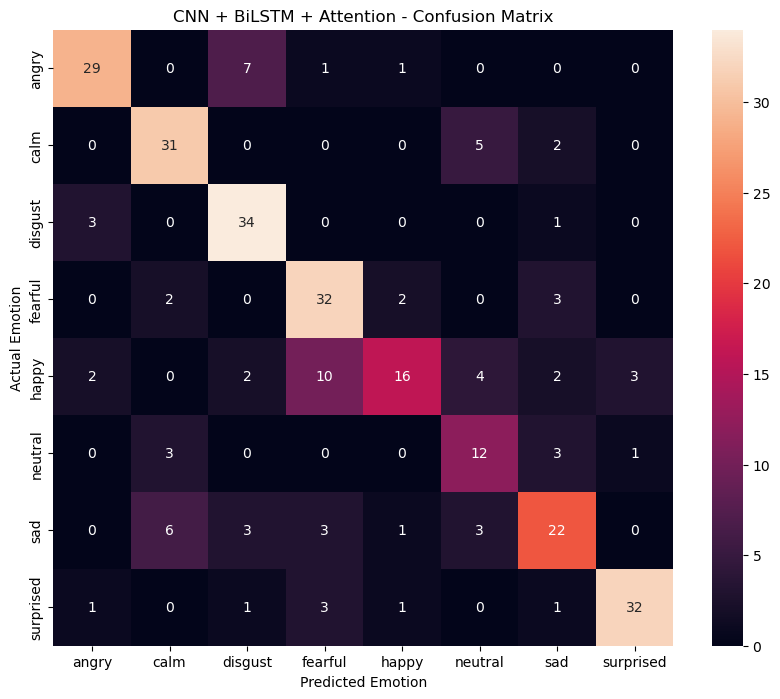

In [67]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    y_test,
    predicted_classes
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")
plt.title("CNN + BiLSTM + Attention - Confusion Matrix")

plt.show()

In [68]:
print(cm)

[[29  0  7  1  1  0  0  0]
 [ 0 31  0  0  0  5  2  0]
 [ 3  0 34  0  0  0  1  0]
 [ 0  2  0 32  2  0  3  0]
 [ 2  0  2 10 16  4  2  3]
 [ 0  3  0  0  0 12  3  1]
 [ 0  6  3  3  1  3 22  0]
 [ 1  0  1  3  1  0  1 32]]


In [69]:
print("Original training samples:", X_train.shape[0])
print("Input shape:", X_train.shape)

Original training samples: 1152
Input shape: (1152, 40, 130, 1)


In [70]:
import os

os.makedirs("models", exist_ok=True)

print("Ready for improved model training.")

Ready for improved model training.


In [71]:
import numpy as np

def augment_mfcc(mfcc):
    augmented = mfcc.copy()

    # Small random noise
    noise = np.random.normal(
        0,
        0.01,
        augmented.shape
    )

    augmented = augmented + noise

    # Small random scaling
    scale = np.random.uniform(0.95, 1.05)

    augmented = augmented * scale

    return augmented

In [72]:
X_aug = np.array([
    augment_mfcc(sample)
    for sample in X_train
])

y_aug = y_train.copy()

print("Original training data:", X_train.shape)
print("Augmented training data:", X_aug.shape)

Original training data: (1152, 40, 130, 1)
Augmented training data: (1152, 40, 130, 1)


In [73]:
X_train_aug = np.concatenate(
    [X_train, X_aug],
    axis=0
)

y_train_aug = np.concatenate(
    [y_train, y_aug],
    axis=0
)

print("Final training data:", X_train_aug.shape)
print("Final training labels:", y_train_aug.shape)

Final training data: (2304, 40, 130, 1)
Final training labels: (2304,)


In [74]:
from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, MaxPooling2D,
    Permute, TimeDistributed, Flatten,
    Bidirectional, LSTM, Dropout, Dense
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

input_layer = Input(shape=(40, 130, 1))

# CNN
x = Conv2D(32, (3, 3), activation="relu", padding="same")(input_layer)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)

x = Conv2D(64, (3, 3), activation="relu", padding="same")(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)

x = Conv2D(128, (3, 3), activation="relu", padding="same")(x)
x = BatchNormalization()(x)

# Convert CNN feature maps to sequence
x = Permute((2, 1, 3))(x)
x = TimeDistributed(Flatten())(x)

# BiLSTM
x = Bidirectional(
    LSTM(128, return_sequences=True)
)(x)

# Attention
x = Attention()(x)

# Classifier
x = Dropout(0.4)(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)

# Output
output_layer = Dense(
    len(encoder.classes_),
    activation="softmax"
)(x)

model_v2 = Model(
    inputs=input_layer,
    outputs=output_layer
)

model_v2.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_v2.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)           │ (None, 40, 130, 1)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 40, 130, 32)         │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 40, 130, 32)         │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 20, 65, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 20, 65, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 20, 65, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 10, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 10, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 10, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ permute_2 (Permute)                  │ (None, 32, 10, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_2 (TimeDistributed) │ (None, 32, 1280)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_2 (Bidirectional)      │ (None, 32, 256)             │       1,442,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ attention_4 (Attention)              │ (None, 256)                 │             288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 8)                   │           1,032 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,570,600 (5.99 MB)

 Trainable params: 1,570,152 (5.99 MB)

 Non-trainable params: 448 (1.75 KB)

In [75]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=0.00001
)

history_v2 = model_v2.fit(
    X_train_aug,
    y_train_aug,
    validation_data=(X_test, y_test),
    epochs=40,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 20s 202ms/step - accuracy: 0.2995 - loss: 1.8428 - val_accuracy: 0.2465 - val_loss: 1.8360 - learning_rate: 5.0000e-04
Epoch 2/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 14s 192ms/step - accuracy: 0.4787 - loss: 1.4213 - val_accuracy: 0.3993 - val_loss: 1.5735 - learning_rate: 5.0000e-04
Epoch 3/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 14s 199ms/step - accuracy: 0.6345 - loss: 1.0484 - val_accuracy: 0.4201 - val_loss: 1.4228 - learning_rate: 5.0000e-04
Epoch 4/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 14s 194ms/step - accuracy: 0.7609 - loss: 0.6924 - val_accuracy: 0.5174 - val_loss: 1.2972 - learning_rate: 5.0000e-04
Epoch 5/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 14s 191ms/step - accuracy: 0.8641 - loss: 0.4065 - val_accuracy: 0.6007 - val_loss: 1.0299 - learning_rate: 5.0000e-04
Epoch 6/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 14s 192ms/step - accuracy: 0.9423 - loss: 0.2101 - val_accuracy: 0.6701 - val_loss: 0.9447 - learning_rate: 5.0000e-04
Epoch 7/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 14s 192ms/step - acc

In [76]:
best_epoch = np.argmax(history_v2.history["val_accuracy"]) + 1
best_val_accuracy = max(history_v2.history["val_accuracy"])

print("Best Epoch:", best_epoch)
print("Best Validation Accuracy:", best_val_accuracy)

Best Epoch: 23
Best Validation Accuracy: 0.8090277910232544


In [77]:
print("Number of epochs completed:", len(history_v2.history["accuracy"]))

Number of epochs completed: 25


In [78]:
test_loss_v2, test_accuracy_v2 = model_v2.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("V2 Test Loss:", test_loss_v2)
print("V2 Test Accuracy:", test_accuracy_v2)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.8056 - loss: 0.7490
V2 Test Loss: 0.7490075826644897
V2 Test Accuracy: 0.8055555820465088


In [79]:
from sklearn.metrics import classification_report
import numpy as np

predictions_v2 = model_v2.predict(
    X_test,
    verbose=1
)

predicted_classes_v2 = np.argmax(
    predictions_v2,
    axis=1
)

print(classification_report(
    y_test,
    predicted_classes_v2,
    target_names=encoder.classes_
))

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step
              precision    recall  f1-score   support

       angry       0.94      0.87      0.90        38
        calm       0.80      0.92      0.85        38
     disgust       0.82      0.95      0.88        38
     fearful       0.69      0.90      0.78        39
       happy       0.88      0.56      0.69        39
     neutral       0.64      0.74      0.68        19
         sad       0.78      0.66      0.71        38
   surprised       0.91      0.82      0.86        39

    accuracy                           0.81       288
   macro avg       0.81      0.80      0.80       288
weighted avg       0.82      0.81      0.80       288



In [80]:
from sklearn.metrics import confusion_matrix

cm_v2 = confusion_matrix(
    y_test,
    predicted_classes_v2
)

print(cm_v2)

[[33  0  4  1  0  0  0  0]
 [ 0 35  0  0  0  2  1  0]
 [ 1  0 36  0  0  0  1  0]
 [ 0  2  0 35  0  0  2  0]
 [ 0  0  1  9 22  3  1  3]
 [ 0  2  0  0  1 14  2  0]
 [ 1  5  2  1  1  3 25  0]
 [ 0  0  1  5  1  0  0 32]]


In [81]:
model_v2.save(
    "models/emotion_cnn_bilstm_attention_v2.keras"
)

print("V2 model saved successfully!")

V2 model saved successfully!


In [82]:
import librosa
import numpy as np
import os

def extract_mfcc_for_prediction(file_path):
    audio, sr = librosa.load(
        file_path,
        sr=16000,
        mono=True
    )

    audio = librosa.util.normalize(audio)

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=40
    )

    mfcc = librosa.util.fix_length(
        mfcc,
        size=130,
        axis=1
    )

    mfcc = mfcc[np.newaxis, ..., np.newaxis]

    return mfcc

In [83]:
voice_files = [
    "test_audio/my_voice.wav",
    "test_audio/normal.wav",
    "test_audio/happy.wav",
    "test_audio/angry.wav"
]

for file_path in voice_files:

    if os.path.exists(file_path):

        X_voice = extract_mfcc_for_prediction(file_path)

        prediction = model_v2.predict(
            X_voice,
            verbose=0
        )

        predicted_index = np.argmax(prediction[0])

        predicted_emotion = encoder.classes_[predicted_index]

        confidence = prediction[0][predicted_index] * 100

        print("\nFile:", file_path)
        print("Predicted Emotion:", predicted_emotion)
        print("Confidence:", round(confidence, 2), "%")

    else:
        print("File not found:", file_path)


File: test_audio/my_voice.wav
Predicted Emotion: calm
Confidence: 100.0 %

File: test_audio/normal.wav
Predicted Emotion: calm
Confidence: 100.0 %

File: test_audio/happy.wav
Predicted Emotion: calm
Confidence: 100.0 %

File: test_audio/angry.wav
Predicted Emotion: calm
Confidence: 99.98 %


In [84]:
for file_path in voice_files:

    X_voice = extract_mfcc_for_prediction(file_path)

    prediction = model_v2.predict(
        X_voice,
        verbose=0
    )[0]

    print("\nFile:", file_path)

    for emotion, probability in zip(
        encoder.classes_,
        prediction
    ):
        print(
            f"{emotion:10s}: {probability * 100:.2f}%"
        )


File: test_audio/my_voice.wav
angry     : 0.00%
calm      : 100.00%
disgust   : 0.00%
fearful   : 0.00%
happy     : 0.00%
neutral   : 0.00%
sad       : 0.00%
surprised : 0.00%

File: test_audio/normal.wav
angry     : 0.00%
calm      : 100.00%
disgust   : 0.00%
fearful   : 0.00%
happy     : 0.00%
neutral   : 0.00%
sad       : 0.00%
surprised : 0.00%

File: test_audio/happy.wav
angry     : 0.00%
calm      : 100.00%
disgust   : 0.00%
fearful   : 0.00%
happy     : 0.00%
neutral   : 0.00%
sad       : 0.00%
surprised : 0.00%

File: test_audio/angry.wav
angry     : 0.00%
calm      : 99.98%
disgust   : 0.01%
fearful   : 0.00%
happy     : 0.00%
neutral   : 0.00%
sad       : 0.00%
surprised : 0.00%


In [85]:
print("X_train shape:", X_train.shape)
print("X_train dtype:", X_train.dtype)

print("First sample:")
print("Min:", X_train[0].min())
print("Max:", X_train[0].max())
print("Mean:", X_train[0].mean())
print("Std:", X_train[0].std())

X_train shape: (1152, 40, 130, 1)
X_train dtype: float32
First sample:
Min: -564.3606
Max: 128.54924
Mean: -10.013511
Std: 66.05844


In [86]:
X_happy = extract_mfcc_for_prediction(
    "test_audio/happy.wav"
)

print("Voice MFCC shape:", X_happy.shape)
print("Min:", X_happy.min())
print("Max:", X_happy.max())
print("Mean:", X_happy.mean())
print("Std:", X_happy.std())

Voice MFCC shape: (1, 40, 130, 1)
Min: -550.0878
Max: 144.38216
Mean: -3.143155
Std: 37.255283


In [87]:
print("X_train sample statistics:")
print("Mean:", np.mean(X_train))
print("Std:", np.std(X_train))

print("\nHappy voice statistics:")
print("Mean:", np.mean(X_happy))
print("Std:", np.std(X_happy))

print("\nDifference in mean:", abs(np.mean(X_train) - np.mean(X_happy)))
print("Difference in std:", abs(np.std(X_train) - np.std(X_happy)))

X_train sample statistics:
Mean: -7.6092515
Std: 60.479008

Happy voice statistics:
Mean: -3.143155
Std: 37.255283

Difference in mean: 4.4660964
Difference in std: 23.223724


In [88]:
mfcc = librosa.feature.mfcc(
    y=audio,
    sr=sr,
    n_mfcc=40
) 

In [89]:
print("Sample rate:", sr) 

Sample rate: 16000


In [91]:
import librosa
import numpy as np

def preprocess_audio(file_path):

    audio, sr = librosa.load(
        file_path,
        sr=16000,
        mono=True
    )

    audio = librosa.util.normalize(audio)

    return audio, sr

print("preprocess_audio function is ready!")

preprocess_audio function is ready!


In [92]:
audio, sr = preprocess_audio("test_audio/happy.wav")

mfcc = librosa.feature.mfcc(
    y=audio,
    sr=sr,
    n_mfcc=40
)

mfcc = librosa.util.fix_length(
    mfcc,
    size=130,
    axis=1
)

print("Audio shape:", audio.shape)
print("Sample rate:", sr)
print("MFCC shape:", mfcc.shape) 

Audio shape: (76459,)
Sample rate: 16000
MFCC shape: (40, 130)


In [93]:
from collections import Counter

print("Training labels:")
print(Counter(y_train))

print("\nTest labels:")
print(Counter(y_test))

print("\nEmotion classes:")
print(encoder.classes_) 

Training labels:
Counter({np.int64(2): 154, np.int64(0): 154, np.int64(6): 154, np.int64(1): 154, np.int64(4): 153, np.int64(7): 153, np.int64(3): 153, np.int64(5): 77})

Test labels:
Counter({np.int64(4): 39, np.int64(3): 39, np.int64(7): 39, np.int64(6): 38, np.int64(1): 38, np.int64(0): 38, np.int64(2): 38, np.int64(5): 19})

Emotion classes:
['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


In [94]:
# Compare average MFCC values

train_mean = np.mean(X_train, axis=0)
voice_mean = np.mean(X_happy, axis=0)

difference = np.mean(np.abs(train_mean - voice_mean))

print("Average MFCC difference:", difference)

Average MFCC difference: 13.306079


In [95]:
audio, sr = librosa.load(
    "test_audio/happy.wav",
    sr=16000,
    mono=True
)

print("Duration:", len(audio) / sr, "seconds")
print("Sample rate:", sr)

Duration: 4.7786875 seconds
Sample rate: 16000


In [96]:
audio, sr = librosa.load(
    "test_audio/happy.wav",
    sr=16000,
    mono=True
)

# Take middle 3 seconds
target_length = 3 * sr
start = (len(audio) - target_length) // 2
audio_middle = audio[start:start + target_length]

# Normalize
audio_middle = librosa.util.normalize(audio_middle)

# MFCC
mfcc = librosa.feature.mfcc(
    y=audio_middle,
    sr=sr,
    n_mfcc=40
)

# Fix to model size
mfcc = librosa.util.fix_length(
    mfcc,
    size=130,
    axis=1
)

# Add batch and channel dimensions
X_happy_middle = mfcc[np.newaxis, ..., np.newaxis].astype("float32")

print("Input shape:", X_happy_middle.shape)

# Prediction
prediction = model_v2.predict(
    X_happy_middle,
    verbose=0
)[0]

print("\nPrediction:")
for emotion, probability in zip(encoder.classes_, prediction):
    print(f"{emotion:10s}: {probability * 100:.2f}%")

predicted_index = np.argmax(prediction)

print("\nPredicted Emotion:", encoder.classes_[predicted_index])
print("Confidence:", round(prediction[predicted_index] * 100, 2), "%")

Input shape: (1, 40, 130, 1)

Prediction:
angry     : 0.00%
calm      : 99.96%
disgust   : 0.03%
fearful   : 0.00%
happy     : 0.00%
neutral   : 0.00%
sad       : 0.00%
surprised : 0.00%

Predicted Emotion: calm
Confidence: 99.96 %


In [98]:
import subprocess

result = subprocess.run(
    ["ffmpeg", "-version"],
    capture_output=True,
    text=True
)

print(result.stdout.splitlines()[0])

ffmpeg version 4.3.1 Copyright (c) 2000-2020 the FFmpeg developers


In [99]:
import subprocess

input_file = "test_audio/my_happy.m4a"
output_file = "test_audio/my_happy.wav"

subprocess.run([
    "ffmpeg",
    "-y",
    "-i", input_file,
    "-ar", "16000",
    "-ac", "1",
    output_file
], check=True)

print("Converted successfully!")
print(output_file)

Converted successfully!
test_audio/my_happy.wav


In [100]:
import subprocess

subprocess.run([
    "ffmpeg", "-y",
    "-i", "test_audio/my_angry.m4a",
    "-ar", "16000",
    "-ac", "1",
    "test_audio/my_angry.wav"
], check=True)

print("Angry converted!")

Angry converted!


In [101]:
import subprocess

subprocess.run([
    "ffmpeg", "-y",
    "-i", "test_audio/my_sad.m4a",
    "-ar", "16000",
    "-ac", "1",
    "test_audio/my_sad.wav"
], check=True)

print("Sad converted!")

Sad converted!


In [102]:
import subprocess

subprocess.run([
    "ffmpeg", "-y",
    "-i", "test_audio/my_surprised.m4a",
    "-ar", "16000",
    "-ac", "1",
    "test_audio/my_surprised.wav"
], check=True)

print("Surprised converted!")

Surprised converted!


In [103]:
import subprocess

subprocess.run([
    "ffmpeg", "-y",
    "-i", "test_audio/normal.m4a",
    "-ar", "16000",
    "-ac", "1",
    "test_audio/my_calm.wav"
], check=True)

print("Calm converted!")

Calm converted!


In [104]:
import os

for file in os.listdir("test_audio"):
    if file.endswith(".wav"):
        print(file)

angry.wav
happy.wav
my_angry.wav
my_calm.wav
my_happy.wav
my_sad.wav
my_surprised.wav
my_voice.wav
normal.wav


In [105]:
voice_files = [
    "test_audio/my_calm.wav",
    "test_audio/my_happy.wav",
    "test_audio/my_angry.wav",
    "test_audio/my_sad.wav",
    "test_audio/my_surprised.wav"
]

for file_path in voice_files:

    X_voice = extract_mfcc_for_prediction(file_path)

    prediction = model_v2.predict(
        X_voice,
        verbose=0
    )[0]

    predicted_index = np.argmax(prediction)

    predicted_emotion = encoder.classes_[predicted_index]
    confidence = prediction[predicted_index] * 100

    print("\nFile:", file_path)
    print("Predicted Emotion:", predicted_emotion)
    print("Confidence:", round(confidence, 2), "%")


File: test_audio/my_calm.wav
Predicted Emotion: calm
Confidence: 100.0 %

File: test_audio/my_happy.wav
Predicted Emotion: calm
Confidence: 99.95 %

File: test_audio/my_angry.wav
Predicted Emotion: calm
Confidence: 99.69 %

File: test_audio/my_sad.wav
Predicted Emotion: calm
Confidence: 99.97 %

File: test_audio/my_surprised.wav
Predicted Emotion: calm
Confidence: 99.19 %


In [106]:
for file_path in voice_files:

    X_voice = extract_mfcc_for_prediction(file_path)

    prediction = model_v2.predict(
        X_voice,
        verbose=0
    )[0]

    print("\n", file_path)

    for emotion, probability in zip(encoder.classes_, prediction):
        print(f"{emotion:10s}: {probability * 100:.4f}%")


 test_audio/my_calm.wav
angry     : 0.0000%
calm      : 99.9998%
disgust   : 0.0001%
fearful   : 0.0000%
happy     : 0.0000%
neutral   : 0.0000%
sad       : 0.0000%
surprised : 0.0000%

 test_audio/my_happy.wav
angry     : 0.0000%
calm      : 99.9461%
disgust   : 0.0529%
fearful   : 0.0000%
happy     : 0.0000%
neutral   : 0.0000%
sad       : 0.0009%
surprised : 0.0000%

 test_audio/my_angry.wav
angry     : 0.0001%
calm      : 99.6880%
disgust   : 0.3095%
fearful   : 0.0000%
happy     : 0.0000%
neutral   : 0.0000%
sad       : 0.0021%
surprised : 0.0002%

 test_audio/my_sad.wav
angry     : 0.0000%
calm      : 99.9739%
disgust   : 0.0202%
fearful   : 0.0000%
happy     : 0.0000%
neutral   : 0.0000%
sad       : 0.0059%
surprised : 0.0000%

 test_audio/my_surprised.wav
angry     : 0.0000%
calm      : 99.1880%
disgust   : 0.8113%
fearful   : 0.0000%
happy     : 0.0000%
neutral   : 0.0000%
sad       : 0.0006%
surprised : 0.0000%


In [111]:
import os

for root, dirs, files in os.walk("."):
    if "attention_history.pkl" in files:
        print("Found:", os.path.join(root, "attention_history.pkl"))

Found: .\models\attention_history.pkl


In [112]:
import pickle

with open("models/attention_history.pkl", "rb") as f:
    history_data = pickle.load(f)

print(type(history_data)) 

<class 'dict'>


In [113]:
print(history_data.keys()) 

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])


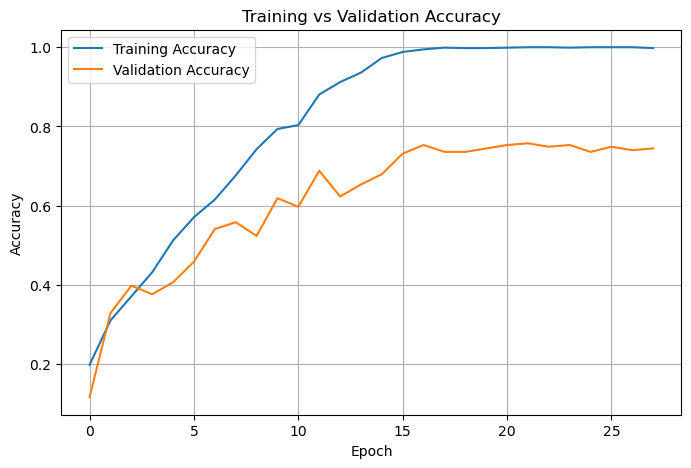

In [114]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history_data["accuracy"], label="Training Accuracy")
plt.plot(history_data["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

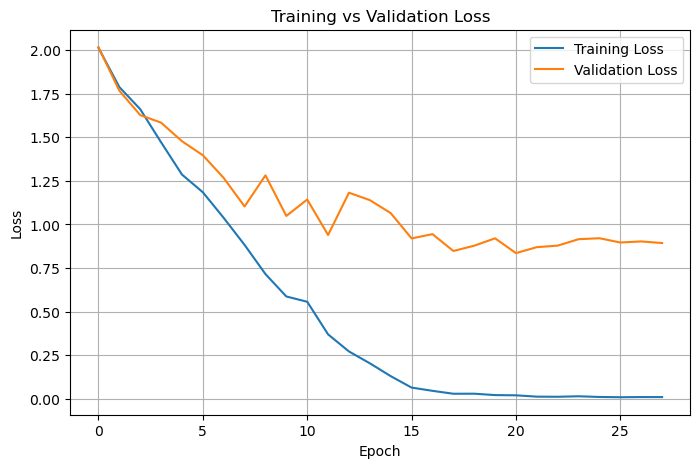

In [115]:
plt.figure(figsize=(8, 5))

plt.plot(history_data["loss"], label="Training Loss")
plt.plot(history_data["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

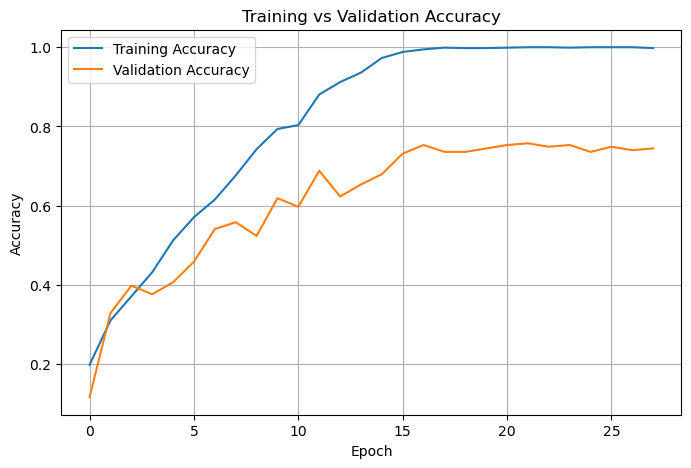

Accuracy graph saved!


In [116]:
plt.figure(figsize=(8, 5))

plt.plot(history_data["accuracy"], label="Training Accuracy")
plt.plot(history_data["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.savefig("models/accuracy_graph.png", dpi=300, bbox_inches="tight")
plt.show()

print("Accuracy graph saved!")

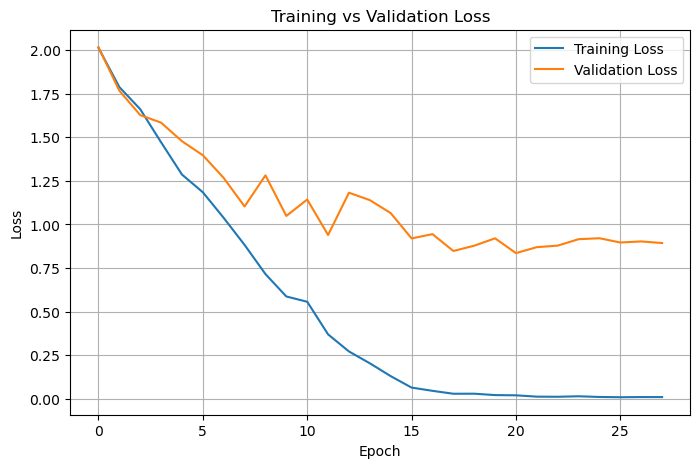

Loss graph saved!


In [117]:
plt.figure(figsize=(8, 5))

plt.plot(history_data["loss"], label="Training Loss")
plt.plot(history_data["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.savefig("models/loss_graph.png", dpi=300, bbox_inches="tight")
plt.show()

print("Loss graph saved!")

In [118]:
import os

os.makedirs("models/final", exist_ok=True)

model_v2.save("models/final/emotion_recognition_final.keras")

print("Final model saved successfully!")

Final model saved successfully!


In [119]:
def predict_emotion(file_path):

    X_voice = extract_mfcc_for_prediction(file_path)

    prediction = model_v2.predict(
        X_voice,
        verbose=0
    )[0]

    predicted_index = np.argmax(prediction)

    emotion = encoder.classes_[predicted_index]
    confidence = prediction[predicted_index] * 100

    print("Audio File:", file_path)
    print("Predicted Emotion:", emotion)
    print("Confidence:", round(confidence, 2), "%")


# Example
predict_emotion("test_audio/my_happy.wav")

Audio File: test_audio/my_happy.wav
Predicted Emotion: calm
Confidence: 99.95 %
